In [4]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.io import decode_image
from torchvision.transforms import v2

In [2]:
training_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

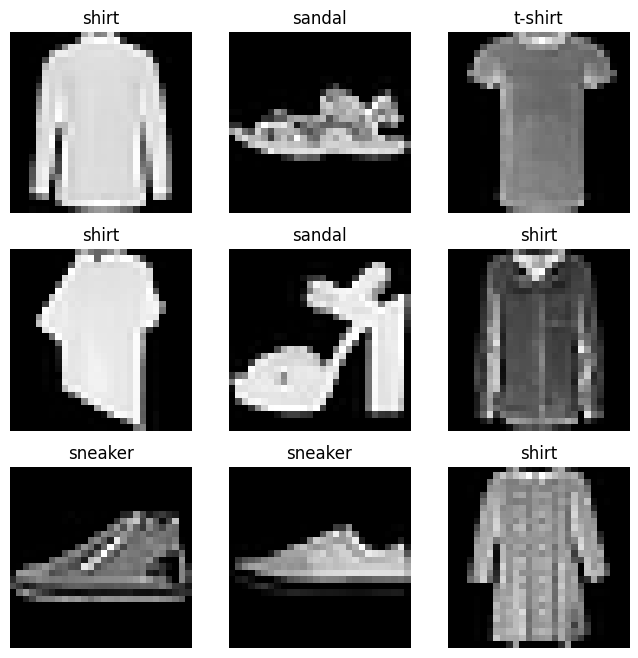

In [3]:
labels_map = {
    0: 't-shirt',
    1: 'pants',
    2: 'pullover',
    3: 'dress',
    4: 'coat',
    5: 'sandal',
    6: 'shirt',
    7: 'sneaker',
    8: 'bag',
    9: 'ankle boot'}
fig = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_i = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_i]
    fig.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis('off')
    plt.imshow(img.squeeze(), cmap='gray')

In [5]:
class CustomImageDataset(Dataset):
    def __init__(
        self, annotations_file, img_dir, tranform=None, target_transform=None
    ):
        self.img_labels = pdd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, i):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[i, 0])
        img = decode_image(img_path)
        label = self.img_labels.iloc[i, 1]
        if self.transform:
            img = self.transform(img)
        if self.target_transform:
            label = self.target_transform(label)
        return img, label